In [1]:
!pip install -q torch triton

In [6]:
import os
import torch

# Set CUTLASS DSL target architecture based on the current GPU.
major, minor = torch.cuda.get_device_capability()
suffix = "a" if major >= 9 else ""
os.environ["CUTE_DSL_ARCH"] = f"sm_{major}{minor}{suffix}"

# Control Divergence in GPU Kernels

**Control divergence** (or warp divergence) occurs when threads within the same warp (group of 32 threads) take different execution paths due to conditional branching. Since all threads in a warp share execution resources, divergent branches must be serialized — the warp executes one path while masking off inactive threads, then executes the other path.

This means:
- **With divergence**: Both branches execute sequentially, and threads idle while waiting for their branch to run. Effective throughput is halved (or worse).
- **Without divergence**: All threads follow the same path, so no serialization penalty occurs.

In this notebook, we write two CUDA kernels compiled via `torch.utils.cpp_extension.load_inline`:
1. A **divergent** kernel where even/odd threads within a warp take different code paths
2. A **non-divergent** kernel that computes the same result without branching

We use `#pragma unroll 1` to prevent the compiler from converting branches into predicated select instructions, which would eliminate the divergence at the PTX level.

We then benchmark both using `triton.testing.do_bench` to measure the performance impact.

In [7]:
import torch
from torch.utils.cpp_extension import load_inline
import triton

## Kernel Definitions (CUDA C)

**Divergent kernel:** branches on `threadIdx.x % 2`. Even and odd threads within every warp take different `if/else` paths. `#pragma unroll 1` prevents the compiler from converting the branches into predicated select instructions.

**Non-divergent kernel:** computes the same result using arithmetic blending (`selector = tid % 2`) so all threads execute the same instruction sequence. No warp serialization occurs.

In [8]:
cuda_src = r"""
#include <torch/extension.h>
#include <cuda_runtime.h>

#define BLOCK_SIZE 256
#define NUM_ITERATIONS 10000

// Divergent: even/odd threads take different if/else paths.
__global__ void divergent_kernel(const float* __restrict__ input,
                                  float* __restrict__ output, int N) {
    int tid = threadIdx.x;
    int idx = blockIdx.x * BLOCK_SIZE + tid;
    if (idx >= N) return;

    float val = input[idx];

    if (tid % 2 == 0) {
        #pragma unroll 1
        for (int i = 0; i < NUM_ITERATIONS; i++) {
            val = val * 0.99f + 0.01f;
        }
    } else {
        #pragma unroll 1
        for (int i = 0; i < NUM_ITERATIONS; i++) {
            val = val * 0.99f + 0.02f;
        }
    }
    output[idx] = val;
}

// Non-divergent: all threads execute the same code path.
__global__ void non_divergent_kernel(const float* __restrict__ input,
                                      float* __restrict__ output, int N) {
    int tid = threadIdx.x;
    int idx = blockIdx.x * BLOCK_SIZE + tid;
    if (idx >= N) return;

    float val = input[idx];
    float add_const = 0.01f + (float)(tid % 2) * 0.01f;

    #pragma unroll 1
    for (int i = 0; i < NUM_ITERATIONS; i++) {
        val = val * 0.99f + add_const;
    }
    output[idx] = val;
}

torch::Tensor launch_divergent(torch::Tensor input) {
    auto output = torch::empty_like(input);
    int N = input.size(0);
    int grid = (N + BLOCK_SIZE - 1) / BLOCK_SIZE;
    divergent_kernel<<<grid, BLOCK_SIZE>>>(input.data_ptr<float>(),
                                            output.data_ptr<float>(), N);
    return output;
}

torch::Tensor launch_non_divergent(torch::Tensor input) {
    auto output = torch::empty_like(input);
    int N = input.size(0);
    int grid = (N + BLOCK_SIZE - 1) / BLOCK_SIZE;
    non_divergent_kernel<<<grid, BLOCK_SIZE>>>(input.data_ptr<float>(),
                                                output.data_ptr<float>(), N);
    return output;
}
"""

cpp_src = """
torch::Tensor launch_divergent(torch::Tensor input);
torch::Tensor launch_non_divergent(torch::Tensor input);
"""

module = load_inline(
    name="control_divergence",
    cpp_sources=cpp_src,
    cuda_sources=cuda_src,
    functions=["launch_divergent", "launch_non_divergent"],
    extra_cuda_cflags=["-O3"],
)

print("Kernels compiled successfully.")

Kernels compiled successfully.


## Correctness Check

Before benchmarking, verify that both kernels produce the same output.

In [9]:
N = 1 << 20  # ~1M elements

input_tensor = torch.randn(N, device="cuda", dtype=torch.float32)

output_divergent = module.launch_divergent(input_tensor)
output_non_divergent = module.launch_non_divergent(input_tensor)

print(f"Outputs match: {torch.allclose(output_divergent, output_non_divergent, atol=1e-4)}")
print(f"Max difference: {(output_divergent - output_non_divergent).abs().max().item():.6e}")

Outputs match: True
Max difference: 0.000000e+00


## Benchmarking with `triton.testing.do_bench`

We use Triton's `do_bench` utility to get reliable GPU kernel timings. It handles warmup, synchronization, and returns percentile-based statistics.

We benchmark across multiple input sizes to see how the divergence penalty scales.

In [10]:
import matplotlib.pyplot as plt

sizes = [2**i for i in range(16, 25)]  # 64K to 16M elements

results = []

print(f"{'N':>12} | {'Divergent (ms)':>15} | {'Non-Divergent (ms)':>19} | {'Speedup':>8}")
print("-" * 65)

for N in sizes:
    x = torch.randn(N, device="cuda", dtype=torch.float32)

    ms_div = triton.testing.do_bench(lambda: module.launch_divergent(x), warmup=25, rep=100)
    ms_nodiv = triton.testing.do_bench(lambda: module.launch_non_divergent(x), warmup=25, rep=100)

    speedup = ms_div / ms_nodiv
    results.append((N, ms_div, ms_nodiv, speedup))
    print(f"{N:>12,} | {ms_div:>15.4f} | {ms_nodiv:>19.4f} | {speedup:>7.2f}x")

           N |  Divergent (ms) |  Non-Divergent (ms) |  Speedup
-----------------------------------------------------------------
      65,536 |          0.5811 |              0.3049 |    1.91x
     131,072 |          0.8859 |              0.4547 |    1.95x
     262,144 |          1.6559 |              0.8498 |    1.95x
     524,288 |          3.1908 |              1.6396 |    1.95x
   1,048,576 |          6.3105 |              3.2465 |    1.94x
   2,097,152 |         12.7330 |              6.5578 |    1.94x
   4,194,304 |         25.3775 |             13.0700 |    1.94x
   8,388,608 |         50.6573 |             26.0966 |    1.94x
  16,777,216 |        101.2797 |             52.1421 |    1.94x


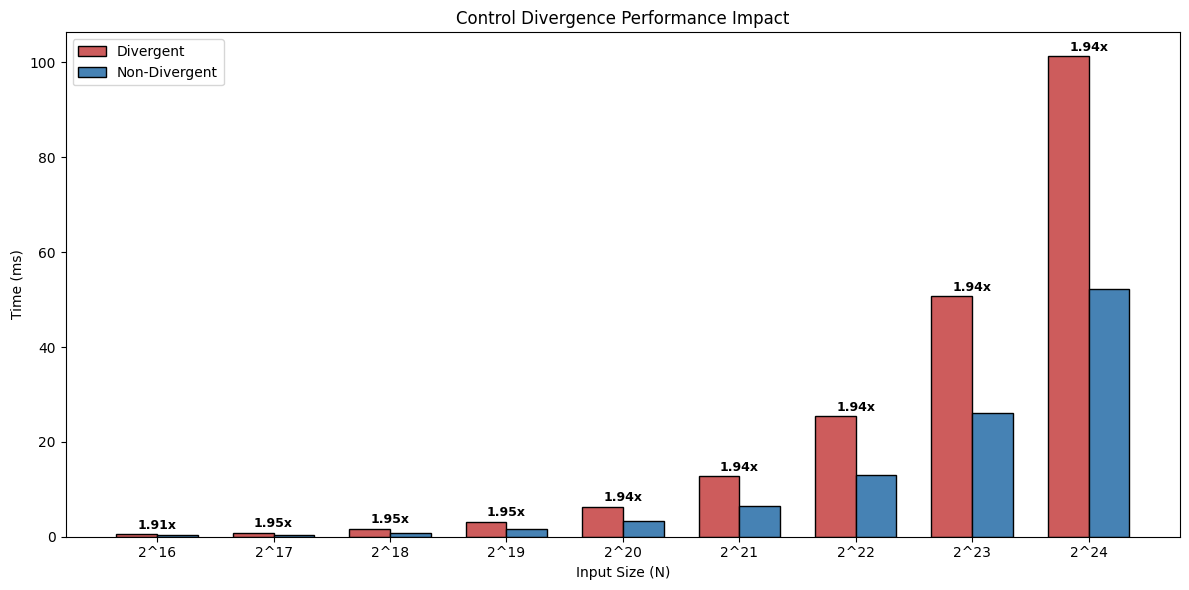

In [11]:
import numpy as np

labels = [f"2^{i}" for i in range(16, 25)]
div_times = [r[1] for r in results]
nodiv_times = [r[2] for r in results]
speedups = [r[3] for r in results]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars_div = ax.bar(x - width / 2, div_times, width, label="Divergent", color="indianred", edgecolor="black")
bars_nodiv = ax.bar(x + width / 2, nodiv_times, width, label="Non-Divergent", color="steelblue", edgecolor="black")

for i, (bd, bn, s) in enumerate(zip(bars_div, bars_nodiv, speedups)):
    top = max(bd.get_height(), bn.get_height())
    ax.text(x[i], top + 0.5, f"{s:.2f}x", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xlabel("Input Size (N)")
ax.set_ylabel("Time (ms)")
ax.set_title("Control Divergence Performance Impact")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.tight_layout()
plt.show()

## Analysis

**Why the divergent kernel is slower:**

In the divergent kernel, every warp hits the `if tid % 2 == 0` branch. Since even and odd threads are interleaved within each warp, the warp must execute both paths — first running the `if` branch (10,000 FMA iterations) with odd threads masked off, then the `else` branch with even threads masked off. The warp effectively does **2x the serial work**.

**Why the non-divergent kernel is faster:**

All threads execute the same instruction stream (`val * 0.99 + add_const`) with different data values. The warp runs one unified loop of 10,000 iterations with all 32 threads active simultaneously. No serialization occurs.

**Why `#pragma unroll 1` matters:**

Without it, the CUDA compiler (nvcc) may convert the `if/else` into predicated `select` instructions — computing both constants and using a predicate to pick the right one. This eliminates the branch entirely at the PTX level, making the "divergent" kernel branchless. `#pragma unroll 1` prevents this optimization by keeping the loop opaque to the compiler.

**Key takeaway:** Avoid branching patterns that split threads within the same warp. When you must branch, try to make the branch condition uniform across the warp (e.g., branch on `warp_id` or `block_idx` rather than `thread_idx % 2`). Alternatively, replace branches with arithmetic blending as shown in the non-divergent kernel.